<a href="https://colab.research.google.com/github/Yujini68/ESAA/blob/main/OB_%EC%BB%A4%EB%A6%AC%ED%81%98%EB%9F%BC_%EB%B3%B5%EC%8A%B5_%EC%8A%A4%ED%84%B0%EB%94%94_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OB 커리큘럼 7,10~13,16주차 복습**

# 01 TEXT MINING for BEGINNER

## DAY 11. 실전 텍스트 분석하기: 단어빈도분석, 연관단어분석

### 1. 단어빈도분석: 문서에서 단어의 출현빈도 계산하기

#### 1.1. 샘플 데이터 불러오기

In [ ]:
# 기사본문을 저장할 리스트를 생성합니다.
article_list = []

# 기사가 저장된 파일은 data 폴더 안에 저장되어 있습니다.
file_path = "/content/article_sample.txt"

# 기사가 저장된 파일을 불러옵니다.
f = open(file_path, encoding="utf-8")
for line in f:
    col = line.strip().split("\t")
    #group = col[0]
    #source = col[1]
    #datetime = col[2]
    #title = col[3]
    # 기사의 본문만 가져와 리스트에 저장합니다.
    content = col[4]
    article_list.append(content)
f.close()

print("총 기사 수 :", len(article_list))

총 기사 수 : 100


In [ ]:
print("기사샘플 :")
print(article_list[3][:1000])

기사샘플 :
10년 역사 10대 뉴스로 정리(지디넷코리아=임유경 기자)2008년 9월 리먼 브라더스 파산으로 촉발된 금융위기가 전 세계를 뒤흔들었다. 세계 금융시스템이 붕괴 위기에 놓여 있던 이때, 인터넷 세상 한 켠에선 새로운 금융 시스템이 조용하게 작동을 시작했다. 10년 전 1월 3일 오후 6시 15분. 은행이나 정부의 개입이 필요 없는 개인 간 전자화폐 시스템 비트코인 네트워크의 첫 번째 블록이 탄생한 순간이다.이날 사토시 나카모토라는 가명의 인물은 앞서 공개한 논문을 통해 제시한 아이디어를 약 한달만에 구현하는 데 성공했다. 기념비적인 첫 번째 블록에는 "재무장관, 은행에 두 번째 구제금융 제공 임박”이라는 문구를 새겼다. 이날 영국 일간지 <타임스>의 1면 헤드라인으로, 비트코인 네트워크가 기존 금융 시스템에 대안적인 성격을 띤다는 정체성을 분명하게 드러냈다.이후 비트코인은 굴곡진 10년의 세월을 보냈다. 2011년 초까지 1달러의 가치도 인정 받지 못했다. 비트코인에 대한 관심도 암호학 커뮤니티 내 개발자들이 재미로 채굴(트랜잭션을 블록단위로 묶어 처리하는 작업)하고 비트코인을 받는 수준에 그쳤다. 이후 관심을 늘었지만 투기기 불법적인 요소 결합돼 버블이니 검은 돈이니 하는 오명을 얻기도 했다.2009년 1월 3일 비트코인 첫 번째 블록인 제네시스 블록이 생성됐다.여전비 비트코인은 실험대 위에 있다. 가격이 출렁일 때마다 "비트코인은 죽었다"는 제목의 기사가 쏟아져 나온다. 지난해 언론에서 내린 사망선고는 거의 100번에 이른다. (☞관련링크)분명한 것은 비트코인의 잠재력을 믿는 사람들이 늘어나고 있다는 점이다. 이제 전 세계 모든 주요 기업들이 비트코인 기반 기술인 블록체인의 혁신성에 주목하고 기존 비즈니스에 적용하기 위해 연구에 나섰다.비트코인 맥시멀리스트로 알려진 지미 송은 최근 자신의 블로그에 비트코인이 가진 특성 중 탈중앙성(정부나 은행의 개입이 없는 상태)에 주목해야 한다고 강조하며 "기업가들은 비트코인 내에서 자신의 돈과 노력을 가지고

#### 1.2. 기사 문장을 형태소 단위로 분리하기

In [ ]:
# 꼬꼬마 형태소 분석기를 불러옵니다.
!pip install konlpy

from konlpy.tag import Kkma
kkma = Kkma()

text = "꼬꼬마 형태소 분석기를 불러옵니다."
print(kkma.pos(text))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 21.2 MB/s eta 0:00:00
[('꼬꼬마', 'NNG'), ('형태소', 'NNG'), ('분석기', 'NNG'), ('를', 'JKO'), ('불러오', 'VV'), ('ㅂ니다', 'EFN'), ('.', 'SF')]


In [ ]:
# 형태소분석 후 기사단위의 형태소 리스트를 저장할 리스트를 생성합니다.
tag_sentence_list = []

# 불용어를 리스트를 정의합니다.
stop_list = ["카페", "카페규정"]

# 형태소 중 꼭 포함해야하는 형태소 태그를 리스트로 생성합니다.
pos_list = ["NNG", "NNP"]

now = 0
for article in article_list:
    now += 1
    print(now, end="\r")
    sentence_list = kkma.sentences(article)
    tag_sentence = []
    for sentence in sentence_list:
        tag_list = kkma.pos(sentence)
        for word, pos in tag_list:
            if pos in pos_list and word not in stop_list and len(word) > 1:
                tag_sentence.append(word)
    tag_sentence_list.append(tag_sentence)

#### 1.3. 형태소 단위로 출현빈도 카운트하기

In [ ]:
# 단어와 빈도를 쌍으로 저장할 딕셔너리를 생성합니다.
word_frequency = {}

for tag_sentence in tag_sentence_list:
    for word in tag_sentence:
        # 단어가 word_frequency의 키(key)값에 존재하는 경우 값(value)만 1을 더하고,
        # 없는 경우에는 1로 초기화합니다.
        if word in word_frequency.keys():
            word_frequency[word] += 1
        else:
            word_frequency[word] = 1

# word_frequency에 저장된 단어의 빈도를 리스트에 저장하고 정렬합니다.
word_count = []
for word, freq in word_frequency.items():
    word_count.append([word, freq])
word_count.sort(key=lambda elem: elem[1], reverse=True)

# 단어의 빈도 상위 N개를 출력합니다.
for word, freq in word_count[:20]:
    print(word + "\t" + str(freq))

금융	873
금리	797
비트	554
부동산	519
대출	505
은행	384
기준	265
시장	190
화폐	185
자산	174
투자	170
당국	149
암호	148
신탁	133
그림자	133
기자	130
거래	120
신용	116
관련	107
정부	103


#### 1.4. 단어빈도를 활용해 워드클라우드 그리기

In [ ]:
# 워드클라우드를 그리기 위해 wordcloud 패키지를 설치합니다.

!pip install wordcloud

In [ ]:
# wordcloud 패키지를 불러옵니다.
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

In [ ]:
# 추출한 단어 리스트를 활용해 명사만으로 이루어진 문자열을 생성합니다.
noun_string = ""

# 명사를 띄어쓰기 구분자로 붙혀줍니다.
for tag_sentence in tag_sentence_list:
    # wordcloud 패키지는 연속되는 단어를 하나로 인식합니다.
    # 단어를 섞어 단어단위로 워드클라우드가 생성될 수 있도록 합니다.
    # random 패키지의 shuffle(LIST) 함수는 리스트의 순서를 랜덤으로 섞어줍니다.
    import random
    random.shuffle(tag_sentence)
    for word in tag_sentence:
        noun_string += word + " "

# 마지막에 붙은 띄어쓰기를 제거합니다.
noun_string = noun_string.strip()

In [ ]:
!sudo apt-get -qq -y install fonts-nanum

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123621 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


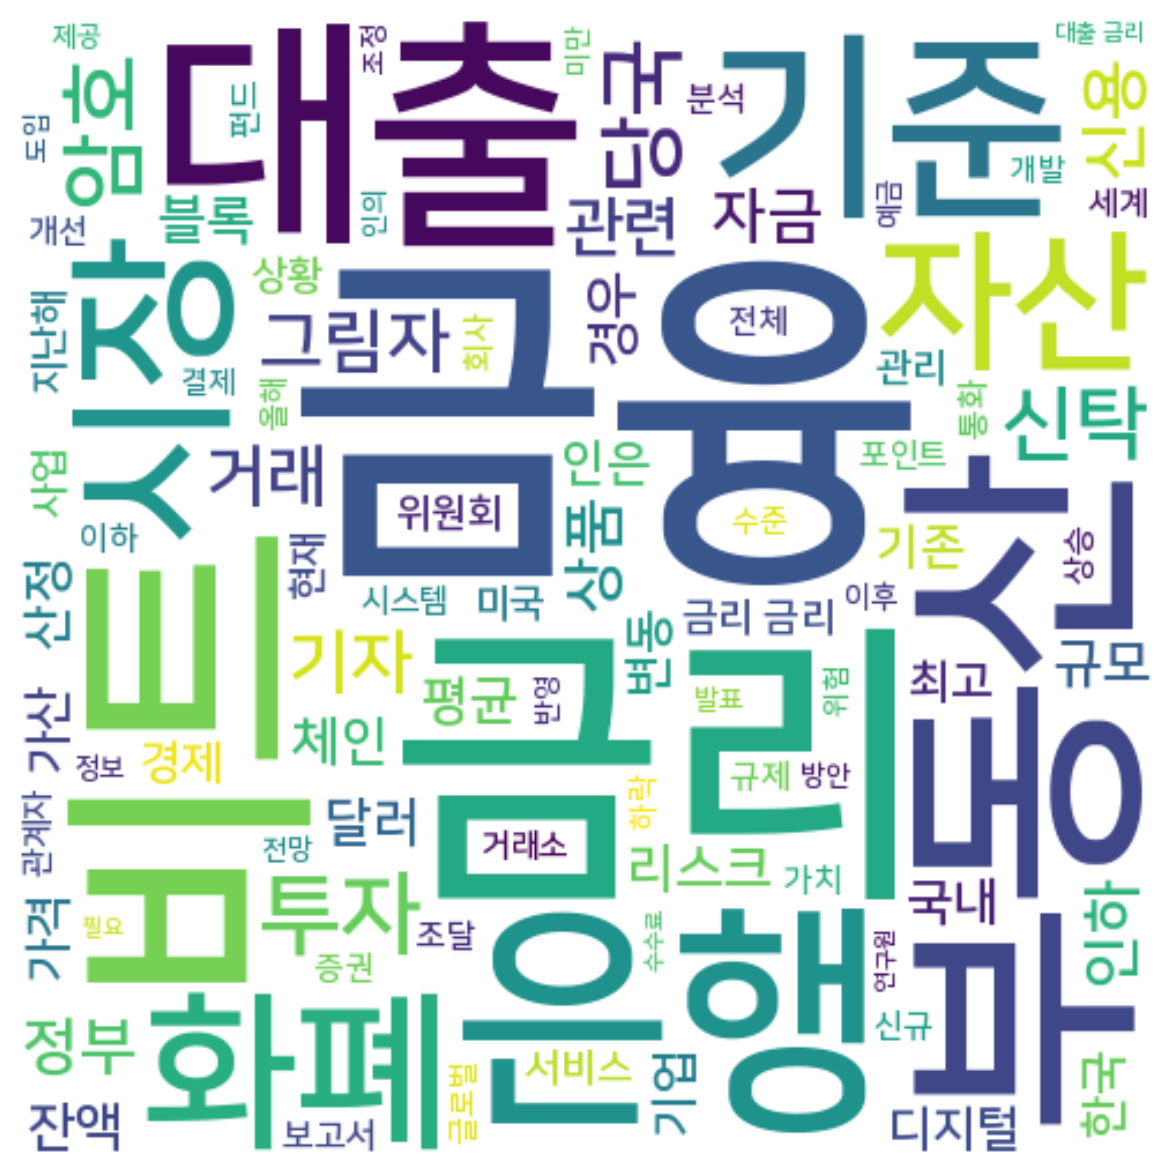

In [ ]:
# 워드클라우드를 생성하고 파일로 저장합니다.

# 워드클라우드 옵션을 선택합니다.
font_path="NanumSquareB"  #폰트
background_color="white"      #배경색
margin=10                     #모서리 여백 넓이
min_font_size=10              #최소 글자 크기
max_font_size=150             #최대 글자 크기
width=500                     #이미지 가로 크기
height=500                    #이미지 세로 크기
wc = WordCloud(font_path=font_path, background_color=background_color, \
               margin=margin, min_font_size=min_font_size, \
               max_font_size=max_font_size, width=width, height=height)
wc.generate(noun_string)

# 생성된 워드클라우드를 이미지로 생성합니다.
plt.figure(figsize=(15, 15))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2. 연관어분석: 문서에서 단어 사이의 동시출현빈도 계산하기

#### 2.3. 단어 기준으로 주변단어 출현빈도 카운트하기
- 2.1, 2.2 과정은 1.1, 1.2 과정과 동일하므로 생략합니다.

In [ ]:
# 연관어를 알아볼 키워드를 지정합니다.
# 키워드는 문서에 반드시 포함된 단어만 지정해야합니다.
keyword = "금리"

# 연관단어와 그 출현빈도를 저장할 딕셔너리를 생성합니다.
co_frequency = {}

for tag_sentence in tag_sentence_list:
    if keyword not in tag_sentence:
        continue
    index = tag_sentence.index(keyword)
    # 연관단어의 정의을 keyword 앞, 뒤의 3단어까지 포함된 단어로 지정합니다.
    window = 3
    co_word_list = tag_sentence[index-window:index+window+1]
    for word in co_word_list:
        # 단어가 co_frequency 키(key)값에 존재하는 경우 값(value)만 1을 더하고,
        # 없는 경우에는 1로 초기화합니다.
        if word in co_frequency.keys():
            co_frequency[word] += 1
        else:
            co_frequency[word] = 1

# co_frequency에 저장된 단어의 빈도를 리스트에 저장하고 정렬합니다.
co_word_list = []
for i, j in co_frequency.items():
    co_word_list.append((i, j))
co_word_list.sort(key=lambda elem: elem[1], reverse=True)

# 연관단어의 빈도 상위 N개를 출력합니다.
for word, frequency in co_word_list[:10]:
    print(word + "\t" + str(frequency))

금리	41
금융	8
이하	7
은행	6
기준	6
대출	6
조정	3
신용	3
개선	3
요구권	3


#### 2.4. 연관단어의 동시출현빈도를 활용해 워드클라우드 그리기

In [ ]:
# 워드클라우드를 그리기 위해 wordcloud 패키지를 설치합니다.

!pip install wordcloud

In [ ]:
# wordcloud 패키지를 불러옵니다.
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

In [ ]:
# 추출한 연관단어 리스트를 활용해 명사만으로 이루어진 문자열을 생성합니다.
noun_string = ""

# 명사를 띄어쓰기 구분자로 붙혀줍니다.
noun_list = []
for word, frequency in co_word_list[:10]:
    for i in range(frequency):
        noun_list.append(word)

# wordcloud 패키지는 연속되는 단어를 하나로 인식합니다.
# 단어를 섞어 단어단위로 워드클라우드가 생성될 수 있도록 합니다.
# random 패키지의 shuffle(LIST) 함수는 리스트의 순서를 랜덤으로 섞어줍니다.
import random
random.shuffle(noun_list)

for word in noun_list:
    noun_string += word + " "

# 마지막에 붙은 띄어쓰기를 제거합니다.
noun_string = noun_string.strip()

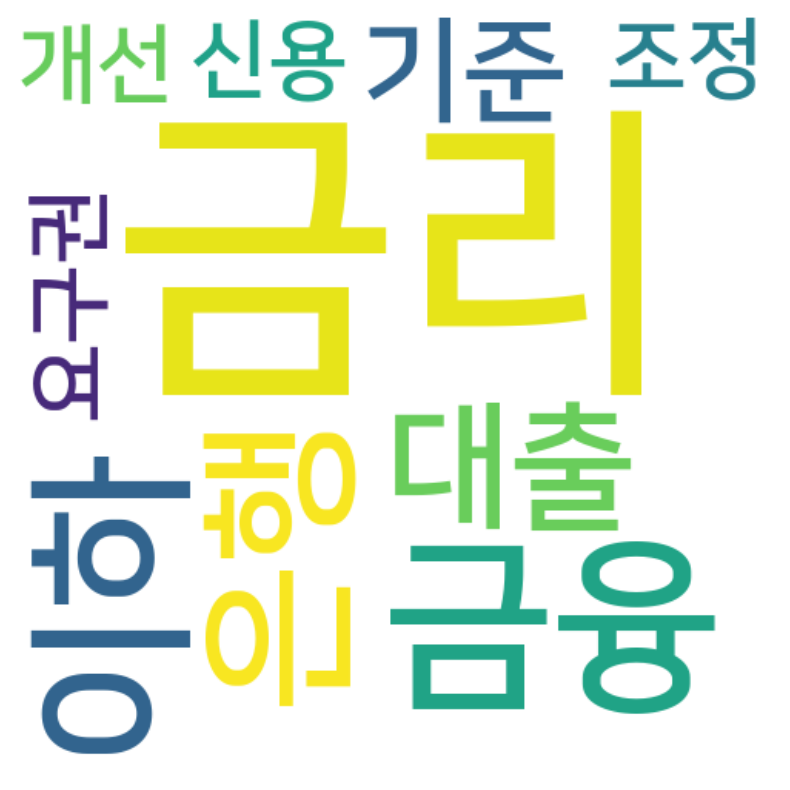

In [ ]:
# 워드클라우드를 생성하고 파일로 저장합니다.

# 워드클라우드 옵션을 선택합니다.
font_path="NanumSquareB"  #폰트
background_color="white"      #배경색
margin=10                     #모서리 여백 넓이
min_font_size=20              #최소 글자 크기
max_font_size=200             #최대 글자 크기
width=500                     #이미지 가로 크기
height=500                    #이미지 세로 크기
wc = WordCloud(font_path=font_path, background_color=background_color, \
               margin=margin, min_font_size=min_font_size, \
               max_font_size=max_font_size, width=width, height=height)
wc.generate(noun_string)

# 생성된 워드클라우드를 이미지로 생성합니다.
plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

## DAY 12. 실전 텍스트 분석하기: LDA토픽모델링, 감성분석

### 1. LDA토픽모델링: 단어를 문서에 포함된 주제단위로 군집화하기

#### 1.1. 샘플 데이터 불러오기

In [ ]:
# 기사본문을 저장할 리스트를 생성합니다.
article_list = []

# 기사가 저장된 파일은 data 폴더 안에 저장되어 있습니다.
file_path = "/content/article_sample.txt"

# 기사가 저장된 파일을 불러옵니다.
f = open(file_path, encoding="utf-8")
for line in f:
    col = line.strip().split("\t")
    #group = col[0]
    #source = col[1]
    #datetime = col[2]
    #title = col[3]
    # 기사의 본문만 가져와 리스트에 저장합니다.
    content = col[4]
    article_list.append(content)
f.close()

print("총 기사 수 :", len(article_list))

총 기사 수 : 100


In [ ]:
print("기사샘플 :")
print(article_list[3][:1000])

기사샘플 :
10년 역사 10대 뉴스로 정리(지디넷코리아=임유경 기자)2008년 9월 리먼 브라더스 파산으로 촉발된 금융위기가 전 세계를 뒤흔들었다. 세계 금융시스템이 붕괴 위기에 놓여 있던 이때, 인터넷 세상 한 켠에선 새로운 금융 시스템이 조용하게 작동을 시작했다. 10년 전 1월 3일 오후 6시 15분. 은행이나 정부의 개입이 필요 없는 개인 간 전자화폐 시스템 비트코인 네트워크의 첫 번째 블록이 탄생한 순간이다.이날 사토시 나카모토라는 가명의 인물은 앞서 공개한 논문을 통해 제시한 아이디어를 약 한달만에 구현하는 데 성공했다. 기념비적인 첫 번째 블록에는 "재무장관, 은행에 두 번째 구제금융 제공 임박”이라는 문구를 새겼다. 이날 영국 일간지 <타임스>의 1면 헤드라인으로, 비트코인 네트워크가 기존 금융 시스템에 대안적인 성격을 띤다는 정체성을 분명하게 드러냈다.이후 비트코인은 굴곡진 10년의 세월을 보냈다. 2011년 초까지 1달러의 가치도 인정 받지 못했다. 비트코인에 대한 관심도 암호학 커뮤니티 내 개발자들이 재미로 채굴(트랜잭션을 블록단위로 묶어 처리하는 작업)하고 비트코인을 받는 수준에 그쳤다. 이후 관심을 늘었지만 투기기 불법적인 요소 결합돼 버블이니 검은 돈이니 하는 오명을 얻기도 했다.2009년 1월 3일 비트코인 첫 번째 블록인 제네시스 블록이 생성됐다.여전비 비트코인은 실험대 위에 있다. 가격이 출렁일 때마다 "비트코인은 죽었다"는 제목의 기사가 쏟아져 나온다. 지난해 언론에서 내린 사망선고는 거의 100번에 이른다. (☞관련링크)분명한 것은 비트코인의 잠재력을 믿는 사람들이 늘어나고 있다는 점이다. 이제 전 세계 모든 주요 기업들이 비트코인 기반 기술인 블록체인의 혁신성에 주목하고 기존 비즈니스에 적용하기 위해 연구에 나섰다.비트코인 맥시멀리스트로 알려진 지미 송은 최근 자신의 블로그에 비트코인이 가진 특성 중 탈중앙성(정부나 은행의 개입이 없는 상태)에 주목해야 한다고 강조하며 "기업가들은 비트코인 내에서 자신의 돈과 노력을 가지고

#### 1.2. 기사 문장을 형태소 단위로 분리하기

In [ ]:
# 꼬꼬마 형태소 분석기를 불러옵니다.
from konlpy.tag import Kkma
kkma = Kkma()

text = "꼬꼬마 형태소 분석기를 불러옵니다."
print(kkma.pos(text))

[('꼬꼬마', 'NNG'), ('형태소', 'NNG'), ('분석기', 'NNG'), ('를', 'JKO'), ('불러오', 'VV'), ('ㅂ니다', 'EFN'), ('.', 'SF')]


In [ ]:
# 형태소분석 후 기사단위의 형태소 리스트를 저장할 리스트를 생성합니다.
tag_sentence_list = []

# 불용어를 리스트를 정의합니다.
stop_list = ["카페", "카페규정"]

# 형태소 중 꼭 포함해야하는 형태소 태그를 리스트로 생성합니다.
pos_list = ["NNG", "NNP"]

now = 0
for article in article_list:
    now += 1
    print(now, end="\r")
    sentence_list = kkma.sentences(article)
    tag_sentence = []
    for sentence in sentence_list:
        tag_list = kkma.pos(sentence)
        for word, pos in tag_list:
            if pos in pos_list and word not in stop_list and len(word) > 1:
                tag_sentence.append(word)
    tag_sentence_list.append(tag_sentence)

#### 1.3. LDA토픽모델링 수행하기

In [ ]:
# 텍스트 분석을 위한 다양한 기능을 제공하는 gensim 패키지를 설치합니다.

!pip install gensim

In [ ]:
# gensim 패키지를 불러옵니다.
import gensim
from gensim import corpora

# LDA토픽모델링 수행중에는 진행중인 상황에 대한 로그가 출력됩니다.
# 아래 7~9번째 줄을 주석처리하면 로그를 확인할 수 있습니다.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

In [ ]:
# 추출할 토픽의 개수를 지정합니다.
topic = 3
# 각 토픽에 포함할 키워드(단어) 개수를 지정합니다.
keyword = 10

# LDA토픽모델링을 수행합니다.
dictionary = corpora.Dictionary(tag_sentence_list)
corpus = [dictionary.doc2bow(text) for text in tag_sentence_list]
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics=topic, id2word = dictionary, passes=10)

# 추출된 토픽과 토픽에 포함된 키워드를 저장할 리스트를 생성합니다.
topic_list = []

# 추출된 토픽을 리스트에 저장합니다.
for num in range(topic):
    topic_list.append(ldamodel.show_topic(num, keyword))

In [ ]:
# 추출된 토픽을 출력합니다.
for index in range(len(topic_list)):
    print("# 주제", index + 1)
    for topic in topic_list[index]:
        print("\t", topic[0].split("/")[0])

# 주제 1
	 비트
	 화폐
	 암호
	 거래
	 달러
	 블록
	 체인
	 금융
	 인은
	 시장
# 주제 2
	 부동산
	 금융
	 그림자
	 신탁
	 투자
	 자산
	 시장
	 은행
	 관련
	 규모
# 주제 3
	 금리
	 대출
	 금융
	 은행
	 기준
	 당국
	 인하
	 평균
	 잔액
	 산정


#### 1.4. LDA토픽모델링 결과 시각화하기

In [ ]:
# LDA토픽모델링 결과를 시각화하는 pyLDAvis 패키지를 설치합니다.

!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 17.0 MB/s eta 0:00:00


In [ ]:
# pyLDAvis 패키지를 불러옵니다.
import pyLDAvis.gensim

# LDA토픽모델링 시각화 결과를 출력합니다.
pyLDAvis.enable_notebook()
lda_display = pyLDAvis.gensim.prepare(ldamodel, corpus, dictionary, sort_topics=True)
pyLDAvis.display(lda_display)

# Intertopic Distance Map의 각 주제가 겹치지 않고 잘 구분되면 적절한 토픽개수라고 볼 수 있습니다.
# 그래프의 분포를 확인하며 토픽의 개수를 조정합니다.
# LDA토픽모델링은 분석 수행시마다 매번 결과가 달라집니다.

### 2. 감성분석: 문장의 감성수준을 수치로 표현하기

#### 2.1. 샘플 데이터 불러오기

In [ ]:
# 영화리뷰을 저장할 리스트를 생성합니다.
review_list = []

# 리뷰가 저장된 파일은 data 폴더 안에 저장되어 있습니다.
# 본 자료에서 제공하는 리뷰는 2019년 개봉작 "엑스맨: 다크 피닉스"의 리뷰입니다.
file_path = "/content/review_sample.txt"

# 리뷰가 저장된 파일을 불러옵니다.
f = open(file_path, encoding="utf-8")
for line in f:
    review_text = line.strip()
    review_list.append(review_text)
f.close()

print("총 리뷰 수 :", len(review_list))

총 리뷰 수 : 1000


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print("리뷰샘플 :")
print(review_list[10])

리뷰샘플 :
이게 마지막이라고?? 정말?? 이렇게 끝낸다고??


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### 2.2. 리뷰 문장을 형태소 단위로 분리하기

In [ ]:
# 꼬꼬마 형태소 분석기를 불러옵니다.
from konlpy.tag import Kkma
kkma = Kkma()

text = "꼬꼬마 형태소 분석기를 불러옵니다."
print(kkma.pos(text))

[('꼬꼬마', 'NNG'), ('형태소', 'NNG'), ('분석기', 'NNG'), ('를', 'JKO'), ('불러오', 'VV'), ('ㅂ니다', 'EFN'), ('.', 'SF')]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# 형태소분석 후 기사단위의 형태소 리스트를 저장할 리스트를 생성합니다.
tag_sentence_list = []

# 불용어를 리스트를 정의합니다.
stop_list = ["카페", "카페규정"]

now = 0
for review in review_list:
    now += 1
    print(now, end="\r")
    tag_list = kkma.pos(review)
    tag_sentence = []
    for word, pos in tag_list:
        tag_sentence.append(word + "/" + pos)
    tag_sentence_list.append(tag_sentence)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print("리뷰 형태소분석 샘플 :")
print("- 원문 :", review_list[10])
print("- 결과 :", tag_sentence_list[10])

리뷰 형태소분석 샘플 :
- 원문 : 이게 마지막이라고?? 정말?? 이렇게 끝낸다고??
- 결과 : ['이것/NP', '이/JKS', '마지막/NNG', '이/VCP', '라고/ECD', '??/SW', '정말/MAG', '??/SW', '이렇/VA', '게/ECD', '끝내/VV', 'ㄴ다고/ECE', '??/SW']


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### 2.3. 감성사전 불러오기

In [ ]:
# KOSAC 감성사전의 내용을 살펴봅니다.
f = open("/content/polarity.csv", encoding="utf-8")
for line in f.read().split("\n")[:10]:
    line = line.strip().split(",")
    print(line)
f.close()

['ngram', 'freq', 'COMP', 'NEG', 'NEUT', 'None', 'POS', 'max.value', 'max.prop']
['가*/JKS', '1', '0', '0', '0', '0', '1', 'POS', '1']
['가*/JKS;있/VV', '1', '0', '0', '0', '0', '1', 'POS', '1']
['가*/JKS;있/VV;었/EP', '1', '0', '0', '0', '0', '1', 'POS', '1']
['가*/VV', '3', '0', '0', '0', '0', '1', 'POS', '1']
['가*/VV;ㄴ다*/EF', '1', '0', '0', '0', '0', '1', 'POS', '1']
['가/JKC', '17', '0', '0.470588235', '0.235294118', '0', '0.294117647', 'NEG', '0.470588235']
['가/JKC;되/VV', '11', '0', '0.363636364', '0.272727273', '0', '0.363636364', 'NEG', '0.363636364']
['가/JKC;되/VV;ㄴ/ETM', '2', '0', '0', '1', '0', '0', 'NEUT', '1']
['가/JKC;되/VV;ㄹ/ETM', '1', '0', '0', '1', '0', '0', 'NEUT', '1']


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# KOSAC 감성사전을 불러와 딕셔너리에 저장합니다.
# 원본 사전에 세미콜론(;)으로 구분된 형태소를 띄어쓰기 단위로 변형하여 딕셔너리의 키(key)값으로 활용합니다.

# 사전을 저장할 딕셔너리를 생성합니다.
sentiment = {}

f = open("polarity.csv", encoding="utf-8")
for line in f:
    col = line.strip().split(",")
    pos = col[0]
    polarity = col[7]
    score = col[8]
    # 극성이 POS인 경우 +, NEG인 경우 -를 곱해 스코어(score)를 계산합니다.
    if polarity == "POS":
        score = float(score)
    elif polarity == "NEG":
        score = -float(score)
    else:
        # 긍정 또는 부정인 경우만 취급합니다.
        continue
    # 세미콜론(;)을 띄어쓰기로 바꿔 딕셔너리에 스코어와 함께 저장합니다.
    sentiment[pos.replace(";", " ")] = score

f.close()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# 생성한 감성사전 딕셔너리 샘플을 출력합니다.

# 긍정
print("(긍정) 솜씨/NNG 는/JX 능숙/XR :", sentiment["솜씨/NNG 는/JX 능숙/XR"])
print("(긍정) 자연/NNG 스럽/XSA :", sentiment["자연/NNG 스럽/XSA"])
print("(긍정) 획일/XR 성/XSN 의/JKG :", sentiment["획일/XR 성/XSN 의/JKG"])
print("(긍정) 훨씬/MAG 안전/NNG :", sentiment["훨씬/MAG 안전/NNG"])
# 부정
print("(부정) 뒷맛/NNG 이/JKS 씁쓸/XR :", sentiment["뒷맛/NNG 이/JKS 씁쓸/XR"])
print("(부정) 손해/NNG 배상/NNG 을/JKO :", sentiment["손해/NNG 배상/NNG 을/JKO"])
print("(부정) 에서/JKB 욕/NNG 튀어나오/VV :", sentiment["에서/JKB 욕/NNG 튀어나오/VV"])
print("(부정) 유달리/MAG 난해/XR :", sentiment["유달리/MAG 난해/XR"])

(긍정) 솜씨/NNG 는/JX 능숙/XR : 1.0
(긍정) 자연/NNG 스럽/XSA : 1.0
(긍정) 획일/XR 성/XSN 의/JKG : 1.0
(긍정) 훨씬/MAG 안전/NNG : 1.0
(부정) 뒷맛/NNG 이/JKS 씁쓸/XR : -1.0
(부정) 손해/NNG 배상/NNG 을/JKO : -1.0
(부정) 에서/JKB 욕/NNG 튀어나오/VV : -1.0
(부정) 유달리/MAG 난해/XR : -1.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### 2.4. 리뷰 감성스코어 계산하기

In [ ]:
# 감성분석 결과를 긍정과 부정 리뷰로 각각 저장할 리스트를 생성합니다.
positive_sentence = []
negative_sentence = []

for tag_sentence, review in zip(tag_sentence_list, review_list):
    # 스코어를 0점으로 초기화합니다.
    score = 0.0
    # 형태소분석된 문장 안에서 최대 7개까지 결합된 형태소가 감성사전 안에 있는지 확인합니다.
    for i in range(len(tag_sentence)):
        max_n = 7
        for n in range(max_n):
            ngram = ""
            for j in range(len(tag_sentence)-n):
                ngram += " " + tag_sentence[j]
            ngram = ngram.strip()
            if ngram in sentiment.keys():
                score += sentiment[ngram]
    # 감성스코어로 긍정 또는 부정을 판단하기위한 임계값을 지정합니다.
    limit = 0
    if score > limit:
        positive_sentence.append(["POSITIVE", str(review)])
    elif score < -limit:
        negative_sentence.append(["NEGATIVE", str(review)])

# 감성분석 결과를 감성스코어를 기준으로 정렬합니다.
positive_sentence.sort(reverse=True)
negative_sentence.sort()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### 2.5. 리뷰 감성분석 결과 확인하기

In [ ]:
print("긍정판별 문장 개수 :", len(positive_sentence))
positive_sentence[:10]

긍정판별 문장 개수 : 27


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[['POSITIVE', '흥미진진 마지막액션씬최고'],
 ['POSITIVE', '하루빨리 통합마블 되기를'],
 ['POSITIVE', '최고최고최고최고최고!'],
 ['POSITIVE', '최고ㅜㅜ 레이븐ㅠㅠㅠ'],
 ['POSITIVE', '장난합니까 마지막 영환데'],
 ['POSITIVE', '은혜를 모르는 진 그레이..'],
 ['POSITIVE', '영화보는데 기빨린다 후하'],
 ['POSITIVE', '영화를 만들다 말았어...'],
 ['POSITIVE', '아주 재밌습니다 후회없음'],
 ['POSITIVE', '생각보다 많이 괜찮은 영화']]

In [ ]:
print("부정판별 문장 개수 :", len(negative_sentence))
negative_sentence[:10]

부정판별 문장 개수 : 13


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[['NEGATIVE', '계속 생각 나는 영화. ㅠㅠ'],
 ['NEGATIVE', '그냥 개똥보다 못한 영화'],
 ['NEGATIVE', '난재밌었어요....'],
 ['NEGATIVE', '내 개인 평점 7.2..;;'],
 ['NEGATIVE', '말이 필요없습니다. 재미있어요'],
 ['NEGATIVE', '스토리 너무 늘어지는듯'],
 ['NEGATIVE', '스토리가 왜이리 이상하냐'],
 ['NEGATIVE', '아쉬움가득안고떠납니다'],
 ['NEGATIVE', '아쉽지만 행복했습니다'],
 ['NEGATIVE', '왜 엑스우먼이 아닌지ㅎ']]

# 02 콘텐츠 기반 필터링 실습 - TMDB 5000 영화 데이터 세트

유명한 영화 데이터 정보 사이트인 IMDB의 많은 영화 중 주요 5000개 영화에 대한 메타 정보를 새롭게 가공해 캐글에서 제공하는 데이터 세트

- 장르 속성을 이용한 영화 콘텐츠 기반 필터링

콘텐츠 기반 필터링 : 사용자가 특정 영화를 감상하고 그 영화를 좋아했다면 그 영화와 비슷한 특성/속성, 구성 요소 등을 가진 다른 영화를 추천하는 것, 영화(또는 상품/서비스) 간의 유사성을 판단하는 기준이 영화를 구성하는 다양한 콘텐츠(장르, 감독, 배우, 평점, 키워드, 영화 설명)를 기반으로 하는 방식

콘텐츠 기반 필터링 추천 시스템을 영화를 선택하는 데 중요한 요소인 영화 장르 속성을 기반으로 만들기 -> 장르 칼럼 값의 유사도를 비교한 뒤 그중 높은 평점을 가지는 영화를 추천하는 방식

- 데이터 로딩 및 가공

In [ ]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies = pd.read_csv('/content/tmdb_5000_movies.csv')
print(movies.shape)
movies.head(1)

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


4803개의 레코드 20개의 피처

영화 제목, 개요, 인기도, 평점, 투표수, 예산, 키워드 등 영화에 대한 다양한 메타 정보

이 중 콘텐츠 기반 필터링 추천 분석에 사용할 주요 칼럼만 추출해 새롭게 DataFrame으로 만들기

In [ ]:
movies_df = movies[['id', 'title', 'genres', 'vote_average', 'vote_count', 'popularity',
                    'keywords', 'overview']]

파이썬 리스트(list) 내부에 여러 개의 딕셔너리가 있는 형태의 문자열로 표기되어 있는 genres, keywords와 같은 칼럼 -> 한꺼번에 여러 개의 값을 표현하기 위한 표기 방식, DataFrame으로 만들어질 때는 단순히 문자열 형태로 로딩되므로 이 칼럼을 가공해야지만 필요한 정보를 추출 가능

해당 칼럼 형태 확인

In [ ]:
pd.set_option('max_colwidth', 100)
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp..."


genres 칼럼 : 여러 개의 개별 장르 데이터, 개별 장르의 명칭은 딕셔너리의 키(Key)인 'name'으로 추출 가능, Keywords 구조 가지고 있음 -> 문자열을 분해해서 개별 장르를 파이썬 리스트 객체로 추출

In [ ]:
from ast import literal_eval

movies_df['genres'] = movies_df['genres'].apply(literal_eval)
movies_df['keywords'] = movies_df['keywords'].apply(literal_eval)

genres 칼럼에서 장르명만 리스트 객체로 추출

In [ ]:
movies_df['genres'] = movies_df['genres'].apply(lambda x : [y['name'] for y in x])
movies_df['keywords'] = movies_df['keywords'].apply(lambda x : [y['name'] for y in x])
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, spa..."


- 장르 콘텐츠 유사도 측정

genres 칼럼을 기반으로 하는 콘텐츠 기반 필터링

1. 문자열로 변환된 genres 칼럼을 Count 기반으로 피처 벡터화 변환한다.

2. genres 문자열을 피처 벡터화 행렬로 변환한 데이터 세트를 코사인 유사도를 통해 비교한다. 이를 위해 데이터 세트의 레코드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체를 생성한다.

3. 장르 유사도가 높은 영화 중에 평점이 높은 순으로 영화를 추천한다.

genres 칼럼을 문자열로 변환한 뒤 사이킷런의 CountVectorizer를 이용해 피처 벡터 행렬로 만들기

In [ ]:
from operator import ge
from sklearn.feature_extraction.text import CountVectorizer

# Countvectorizer를 적용하기 위해 공백문자로 word 단위가 구분되는 문자열로 변환
movies_df['genres_literal'] = movies_df['genres'].apply(lambda x : (' ').join(x))
count_vect = CountVectorizer(min_df=1, ngram_range=(1,2))
genre_mat = count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


CountVectorizer로 변환해 4803개의 레코드와 276개의 개별 단어 피처로 구성된 피처 벡터 행렬이 만들어짐 -> 사이킷런의 cosine_similarity()를 이용해 코사인 유사도를 계산

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

genre_sim = cosine_similarity(genre_mat, genre_mat)
print(genre_sim.shape)
print(genre_sim[:2])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]
 [0.59628479 1.         0.4        ... 0.         0.         0.        ]]


genre_sim 객체의 기준 행별로 비교 대상이 되는 행의 유사도 값이 높은 순으로 정렬된 행렬의 위치 인덱스 값을 추출

높은 순으로 정렬된 비교 행 위치 인덱스 값을 가져오고 그 중에 0번 레코드의 비교 행 위치 인덱스 값만 샘플로 추출

In [ ]:
genre_sim_sorted_ind = genre_sim.argsort()[:, ::-1]
print(genre_sim_sorted_ind[:1])

[[   0 3494  813 ... 3038 3037 2401]]


0번 레코드의 경우 자신인 0번 레코드를 제외하면 3494번 레코드가 유사도가 가장 높고 813번, 2401번 레코드 순으로 유사도가 낮음

genre_sim_sorted_ind 객체 : 각 레코드의 장르 코사인 유사도가 가장 높은 순으로 정렬된 타레코드의 위치 인덱스 값을 가지고 있음 -> 특정 레코드와 코사인 유사도가 높은 다른 레코드를 추출할 수 있음

- 장르 콘텐츠 필터링을 이용한 영화 추천

장르 유사도에 따라 영화를 추천하는 함수 생성

In [ ]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):

  # 인자로 입력된 movies_df DataFrame에서 'title' 칼럼이 입력된 title_name 값인 DataFrame 추출
  title_movie = df[df['title'] == title_name]

  # title_name을 가진 DataFrame의 index 객체를 ndarray로 반환하고
  # sorted_ind 인자로 입력된 genre_sim_sorted_ind 객체에서 유사도 순으로 top_n개의 index 추출
  title_index = title_movie.index.values
  similar_indexes = sorted_ind[title_index, :(top_n)]

  # 추출된 top_n index 출력. top_n index는 2차원 데이터임.
  # dataframe에서 index로 사용하기 위해서 1차원 array로 변경
  print(similar_indexes)
  similar_indexes = similar_indexes.reshape(-1)

  return df.iloc[similar_indexes]

find_sim_movie() 함수를 이용해 영화 '대부'와 장르별로 유사한 영화 10개를 추천

In [ ]:
similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average']]

[[2731 1243 3636 1946 2640 4065 1847 4217  883 3866]]


,title,vote_average
2731,The Godfather: Part II,8.3
1243,Mean Streets,7.2
3636,Light Sleeper,5.7
1946,The Bad Lieutenant: Port of Call - New Orleans,6.0
2640,Things to Do in Denver When You're Dead,6.7
4065,Mi America,0.0
1847,GoodFellas,8.2
4217,Kids,6.8
883,Catch Me If You Can,7.7
3866,City of God,8.1


더 많은 후보군을 선정한 뒤에 영화의 평점에 따라 필터링해서 최종 추천하는 방식으로 변경

영화의 평점 정보인 'vote_average' 값을 이용

소수의 관객이 특정 영화에 만점이나 매우 높은 평점을 부여해 왜곡된 데이터를 가지고 있을 수 있으므로 이를 확인하기 위해 sort_values()를 이용해 평점 오름차순으로 movies_df를 정렬해서 10개만 출력

In [ ]:
movies_df[['title', 'vote_average', 'vote_count']].sort_values('vote_average', ascending=False)[:10]

,title,vote_average,vote_count
3519,Stiff Upper Lips,10.0,1
4247,Me You and Five Bucks,10.0,2
4045,"Dancer, Texas Pop. 81",10.0,1
4662,Little Big Top,10.0,1
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
2970,There Goes My Baby,8.5,2
1881,The Shawshank Redemption,8.5,8205
2796,The Prisoner of Zenda,8.4,11
3337,The Godfather,8.4,5893


왜곡된 평점 데이터를 회피할 수 있도록 평점에 평가 횟수를 반영할 수 있는 새로운 평가 방식이 필요

평가 횟수에 대한 가중치가 부여된 평점(Weighted Rating) 방식을 사용

가중 평점의 공식 :
가중평점(Weighted Rating) = (v/(v+m)) * R + (m/(v+m)) * c

v: 개별 영화에 평점을 투표한 횟수

m: 평점을 부여하기 위한 최소 투표 횟수

R: 개별 영화에 대한 평균 평점

C: 전체 영화에 대한 평균 평점

In [ ]:
C = movies_df['vote_average'].mean()
m = movies_df['vote_count'].quantile(0.6)
print('C:', round(C, 3), 'm:', round(m,3))

C: 6.092 m: 370.2


기존 평점을 새로운 가중 평점으로 변경하는 함수를 생성하고 이를 이용해 새로운 평점 정보인 vote_weighted 값 생성

In [ ]:
percentile = 0.6
m = movies_df['vote_count'].quantile(percentile)
C = movies_df['vote_average'].mean()

def weighted_vote_average(record):
  v = record['vote_count']
  R = record['vote_average']

  return ((v/(v+m)) * R) + ((m/(m+v)) * C)

movies_df['weighted_vote'] = movies.apply(weighted_vote_average, axis=1)

새롭게 부여된 weighted_vote 평점이 높은 순으로 상위 10개의 영화를 추출

In [ ]:
movies_df[['title', 'vote_average', 'weighted_vote', 'vote_count']].sort_values('weighted_vote', ascending=False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


새롭게 정의된 평점 기준에 따라 영화를 추천

장르 유사성이 높은 영화를 top_n의 2배수만큼 후보군으로 선정한 뒤에 weighted_vote 칼럼이 높은 순으로 top_n만큼 추출하는 방식으로 find_sim_movie() 함수를 변경

In [ ]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):
  title_movie = df[df['title'] == title_name]
  title_index = title_movie.index.values

  # top_n의 2배에 해당하는 장르 유사성이 높은 인덱스 추출
  similar_indexes = sorted_ind[title_index, :(top_n*2)]
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes != title_index]

  # top_n의 2배에 해당하는 후보군에서 weighted_vote가 높은 순으로 top_n만큼 추출
  return df.iloc[similar_indexes].sort_values('weighted_vote', ascending=False)[:top_n]

similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average', 'weighted_vote']]

,title,vote_average,weighted_vote
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
883,Catch Me If You Can,7.7,7.557097
281,American Gangster,7.4,7.141396
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525
1243,Mean Streets,7.2,6.626569
2839,Rounders,6.9,6.530427


장르만으로 영화가 전달하는 많은 요소와 분위기, 그리고 개인이 좋아하는 성향을 반영하기에는 부족할 수 있기 때문에 앞의 장르를 기반으로 좀 더 다양한 콘텐츠 기반으로 확장 가능

# 03 이미지 분할(Segmentation)

- 이미지를 구성하는 모든 픽셀에 대해 픽셀 단위로 분류하는 것
- 모든 픽셀은 어떤 클래스에 속함
- 모든 픽셀에 대한 정답 클래스를 레이블 처리한 데이터셋을 가지고 딥러닝 모델을 훈련시키면 정답 클래스를 알지 못하는 새로운 이미지에 대해서도 배경과 객체 분리 가능

- 의미 분할 : 같은 범주의 여러 객체를 하나의 범주로 묶어서 구분
- 인스턴스 분할 : 같은 범주에 속하더라도 서로 다른 객체를 구분

## 7-1 데이터셋 준비
- Oxford-IIIT Pet Dataset
- 반려동물의 이미지 및 분류 레이블, 각 이미지를 구성하는 픽셀 단위의 마스크로 구성
- 마스크 : 각 픽셀에 대한 범주 레이블

- class 1 : 반려동물이 속한 픽셀
- class 2 : 반려동물과 인접한 픽셀
- class 3 : 위에 속하지 않는 경우/주변 픽셀

In [ ]:
# 영상 처리를 위한 라이브러리 불러오기
import numpy as np
import tensorflow as tf
import matplotlib.pylab as plt
import cv2
from tqdm.notebook import tqdm
import tensorflow_datasets as tfds
from google.colab.patches import cv2_imshow

In [ ]:
# 모델 학습에 필요한 입력 이미지의 크기와 학습 파라미터 설정
# 이미지 크기
img_w = 128
img_h = 128
img_c = 3
img_shape = (img_w, img_h, img_c)

# 모델 학습
epoch_num = 5
learning_rate = 0.0001
buffer_size = 1000
batch_size = 16

- 주요 파라미터 정리 -> 모델의 세부 튜닝 작업 효율적으로 가능

In [ ]:
# 텐서플로 데이터셋 로드
ds_str = 'oxford_iiit_pet'
ds, info = tfds.load(name=ds_str, with_info = True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/3680 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.1K8JG2_3.2.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...:   0%|          | 0/3669 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.1K8JG2_3.2.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/3.2.0. Subsequent calls will reuse this data.


In [ ]:
# 이미지 전처리 함수(원본 이미지와 분할 마스크에 적용할 것)
def preprocess_image(ds):
  # 원본 이미지
  img = tf.image.resize(ds['image'], (img_w, img_h))
  img = tf.cast(img, tf.float32) / 255.0
  # 분할 마스크
  mask = tf.image.resize(ds['segmentation_mask'], (img_w, img_h))
  mask = tf.cast(mask, tf.int32)
  mask = mask - 1
  return img, mask

In [ ]:
# 데이터 전처리 파이프라인
## 앞에서 정의한 전처리 함수를 훈련 셋, 테스트 셋에 매핑해 주고 미니배치로 분할
train_ds = ds['train'].map(preprocess_image).shuffle(buffer_size).batch(batch_size).prefetch(2)
test_ds = ds['test'].map(preprocess_image).shuffle(buffer_size).batch(batch_size).prefetch(2)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.int32, name=None))>


In [ ]:
# 샘플 배치 선택
img, mask = next(iter(train_ds))
len(img)

16

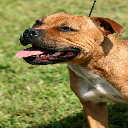

In [ ]:
# 샘플 이미지 출력
img = np.array(img[0]) * 255.0
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2_imshow(img)

In [ ]:
# 샘플 마스크 출력
mask = (np.array(mask[0])/2) * 255.0
cv2_imshow(mask)

## 7-2 U-Net 모델(인코더-디코더)

- 사전 학습된 VGG16 모델을 인코더로 활용하는 U-Net 모델 만들기
- 사전 학습된 모델 없이도 데이터의 개수와 시간이 충분하다면, U-Net을 구성하여 학습을 진행할 수 있음, 데이터 개수와 시간이 충분하다는 전제
- 구글 코랩 환경에서 제한된 자원으로 양호한 성능을 갖는 모델을 만들기 위해서 사전 학습된 모델을 베이스모델로 활용하는 전이 학습 방법 사용
- VGG16 모델을 최종 레이어를 제외한 채로 불러오기

In [ ]:
# VGG16 모델
base_model = tf.keras.applications.VGG16(input_shape=img_shape, include_top = False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- VGG16 모델은 합성곱 층과 풀링 층을 직렬로 연결한 구조
- 인코더 : 원본 이미지 중에서 같은 범주에 속하는 픽셀을 결합하면서 점진적으로 이미지를 더 작은 크기로 축소, 마스크 정답을 활용하여 각 픽셀의 마스크 범주를 0,1,2 중에서 하나로 분류하는 역

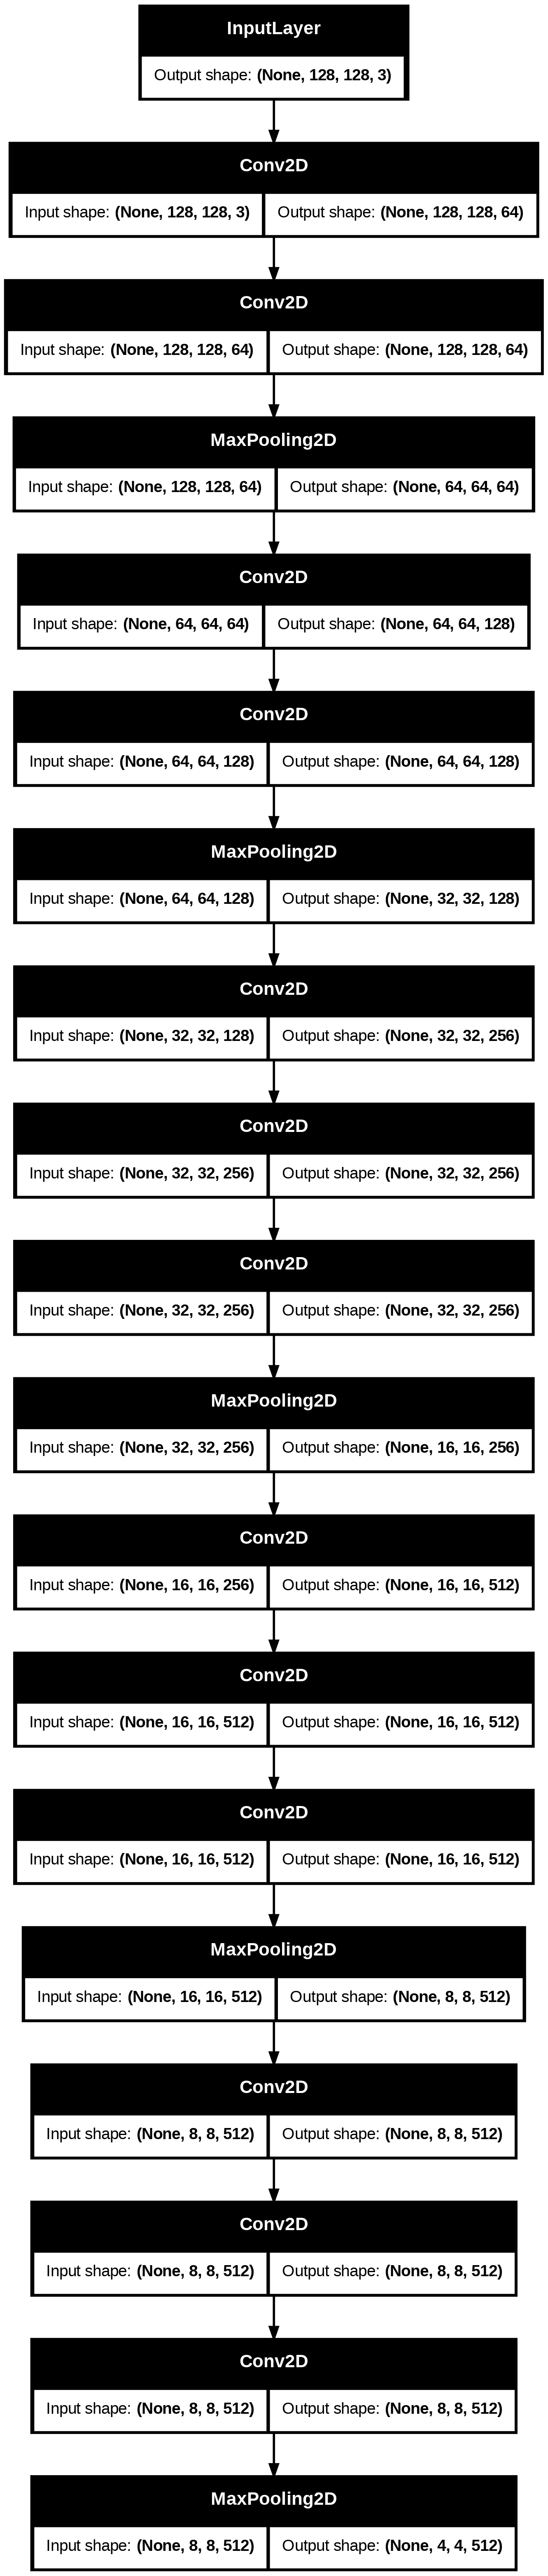

In [ ]:
# 모델 구조
tf.keras.utils.plot_model(base_model, show_shapes=True)

- 만들고자 하는 U-net의 모양을 미리 정하고, 사전 학습된 모델에서 어느 부분의 어떤 shape의 출력을 가져올지 먼저 정함
- VGG16 모델의 중간 레이어 중에서 필요한 출력 텐서를 지정하여 다양한 피처(특징)를 추출하는 인코더 모델의 정의

In [ ]:
# VGG16 중간 레이어 출력 텐서를 지정
f_model = tf.keras.Model(inputs=[base_model.input],
                         outputs=[
                             base_model.get_layer(name='block5_conv3').output,
                             base_model.get_layer(name='block4_conv3').output,
                             base_model.get_layer(name='block3_conv3').output,
                             base_model.get_layer(name='block2_conv2').output,
                             base_model.get_layer(name='block1_conv2').output
                         ])

In [ ]:
# 파라미터 고정
## 사전 학습된 파라미터를 인코더에 그대로 사용하기 위해 업데이트되지 않도록 고정
f_model.trainable = False

- 업샘플링 : 축소된 이미지를 원래 이미지 크기로 복원하는 과정

In [ ]:
# U-Net 구조로 모델 정의

i = tf.keras.Input(shape=img_shape)

out_8_8_512, out_16_16_512, out_32_32_256, out_64_64_128, out_128_128_64 = f_model(i)

out = tf.keras.layers.Conv2DTranspose(512,3,strides=2,padding='same')(out_8_8_512)
out = tf.keras.layers.Add()([out, out_16_16_512])

out = tf.keras.layers.Conv2DTranspose(256, 3, strides=2, padding='same')(out)
out = tf.keras.layers.Add()([out, out_32_32_256])

out = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same')(out)
out = tf.keras.layers.Add()([out, out_64_64_128])

out = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same')(out)
out = tf.keras.layers.Add()([out, out_128_128_64])

out = tf.keras.layers.Conv2D(3,3,activation='elu',padding='same')(out)
out = tf.keras.layers.Dense(3, activation='softmax')(out)

unet_model = tf.keras.Model(inputs=[i], outputs=[out])

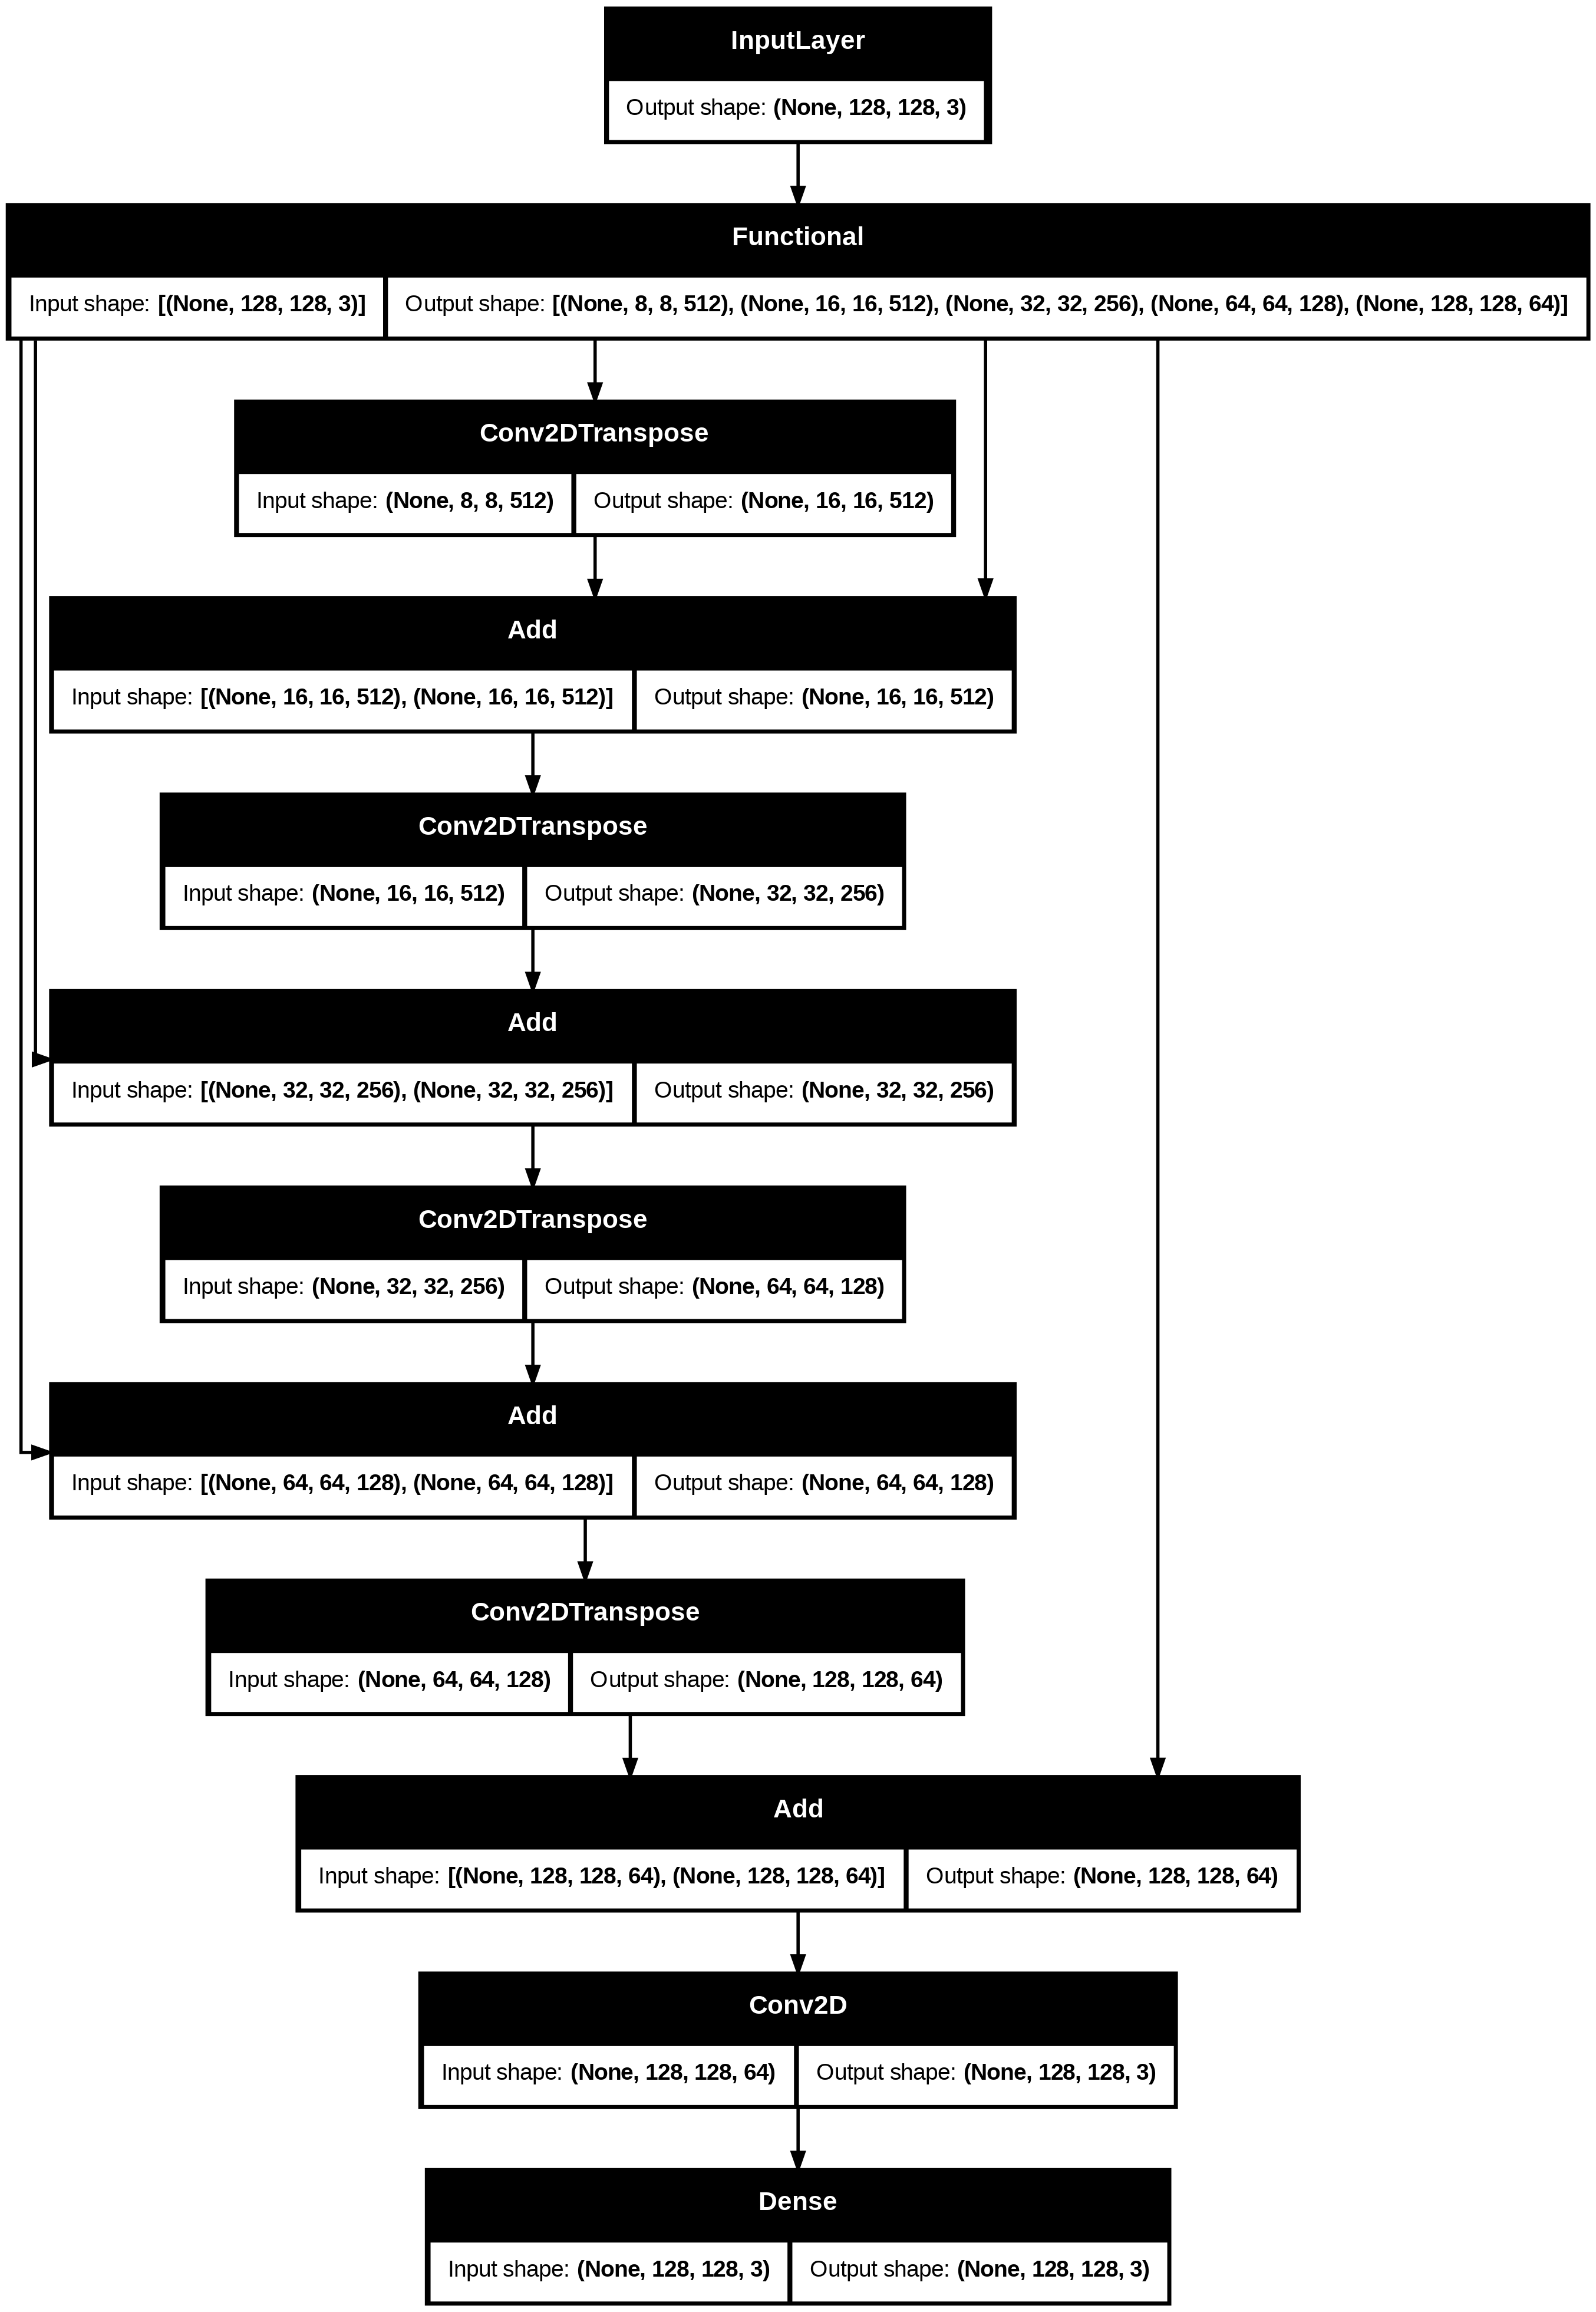

In [ ]:
# 모델 구조 시각화
tf.keras.utils.plot_model(unet_model, show_shapes=True)

- 인코더의 중간 출력이 업샘플링 과정에서 디코더의 중간 출력과 합쳐지는 것을 확인할 수 있음

In [ ]:
# 모델 요약
unet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ [(None, 8, 8, 512),    │     14,714,688 │ input_layer_1[0][0]    │
│                           │ (None, 16, 16, 512),   │                │                        │
│                           │ (None, 32, 32, 256),   │                │                        │
│                           │ (None, 64, 64, 128),   │                │                        │
│                           │ (None, 128, 128, 64)]  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 16, 16, 512)    │      2,359,808 │ functional[0][0]       │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 16, 16, 512)    │              0 │ conv2d_transpose[0][0… │
│                           │                        │                │ functional[0][1]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1        │ (None, 32, 32, 256)    │      1,179,904 │ add[0][0]              │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 32, 32, 256)    │              0 │ conv2d_transpose_1[0]… │
│                           │                        │                │ functional[0][2]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_2        │ (None, 64, 64, 128)    │        295,040 │ add_1[0][0]            │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 64, 64, 128)    │              0 │ conv2d_transpose_2[0]… │
│                           │                        │                │ functional[0][3]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_3        │ (None, 128, 128, 64)   │         73,792 │ add_2[0][0]            │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 128, 128, 64)   │              0 │ conv2d_transpose_3[0]… │
│                           │                        │                │ functional[0][4]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 3)    │          1,731 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128, 128, 3)    │             12 │ conv2d[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 18,624,975 (71.05 MB)

 Trainable params: 3,910,287 (14.92 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# 모델 컴파일 및 훈련
loss_f = tf.losses.SparseCategoricalCrossentropy()
opt = tf.optimizers.Adam(learning_rate)

unet_model.compile(optimizer=opt, loss=loss_f, metrics=['accuracy'])
unet_model.fit(train_ds, batch_size=batch_size, epochs=epoch_num)

Epoch 1/5
230/230 [==============================] - 1487s 6s/step - loss: 0.8897 - accuracy: 0.5491
Epoch 2/5
230/230 [==============================] - 1447s 6s/step - loss: 0.5730 - accuracy: 0.7338
Epoch 3/5
230/230 [==============================] - 1481s 6s/step - loss: 0.5253 - accuracy: 0.7624
Epoch 4/5
230/230 [==============================] - 1448s 6s/step - loss: 0.4998 - accuracy: 0.7769
Epoch 5/5
230/230 [==============================] - 1454s 6s/step - loss: 0.4851 - accuracy: 0.7843


1/1 [==============================] - 4s 4s/step


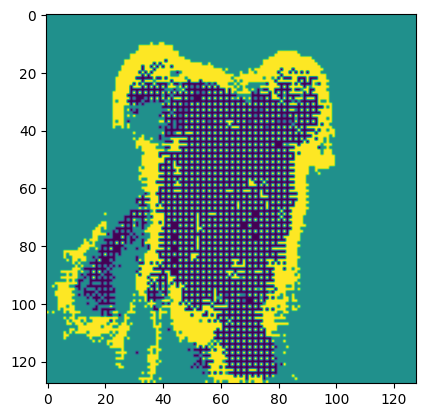

In [ ]:
# 1개 배치(16개 이미지)를 선택
img, mask = next(iter(test_ds))

# 모델 예측
pred = unet_model.predict(img)

# 첫번째 이미지 분할 결과를 출력
pred_img = np.argmax(pred[0], -1)
plt.imshow(pred_img)

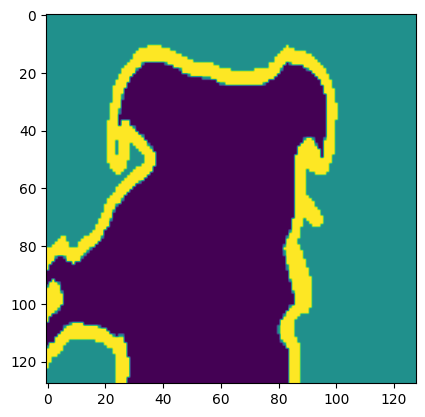

In [ ]:
# 첫번째 이미지의 정답 마스크 출력
plt.imshow(np.reshape(mask[0],(128,128)))